# Rust in the Boiler — Spotting the Liars in Your Domain

**Four layers to find the permissions whose name says one thing and whose privileges say another — classical analysis and local AI, nothing leaves your machine.**

Luis F. Monge (@Lucky-Luk3) · [grexid.eu](https://grexid.eu) · CERT-EU Annual Conference 2026 · CC BY 4.0

This is the guided demo shown in the talk. Every phase is **one instruction and one cell**. All the machinery lives in `boiler.py`, next to this notebook — open it if you want to see how each step works or to tune it.

| Phase | Layer | You run | You get |
|---|---|---|---|
| 1 | Data | `config_menu()` or `load_saved()` | `df_users`, `df_groups` |
| 2 | **Steel** · Risk scoring | `risk_ranking(df_groups)` | top-N by explainable risk score |
| 3 | **Steel** · Graph | `domain_map(df_groups)` | the shape of the domain |
| 4 | **Steam** · Anomaly consensus | `anomaly_consensus(df_groups)` | top-N anomalies, each with its reason |
| 5 | **Steam** · Local AI | `semantic_search` · `incoherence` · `llm_explain` | the liars, explained |
| 6 | Full circle | `inspect(ml)` | one group, all four layers |

## 0 · Before you start

* A folder with the **SharpHound JSON** collection and a running **BloodHound CE** with an API token.
* `boiler.py` and `certeu_utils.py` in the same folder as this notebook.
* [Ollama](https://ollama.com) installed and `ollama pull llama3.2:3b` (phase 5.3 only). The embedding model downloads itself on first use (~80 MB).

In [1]:
#!pip install pandas numpy requests tqdm ipywidgets ipyfilechooser plotly scikit-learn scipy sentence-transformers ollama
from boiler import *

## 1 · Collect — the data is already in your house

SharpHound is the unsung hero: the same collection your red team runs is the input here. Fill in the BloodHound CE details, pick the folder and press **Process data**. The first run asks the API for every user and group — on a large domain it takes a while — and saves `users.csv` / `groups.csv`. Tick *Use saved data* to skip that on later runs.

In [2]:
config_menu()

Already processed on another machine? Load the two CSVs instead and jump straight to phase 2.

In [ ]:
# df_users, df_groups = load_saved()

## 2 · Steel · Risk scoring — from mess to order

One number per object, built from what the graph knows: what it can control, who can control it, how far it is from Domain Admins, how many other paths run through it. Deterministic, transparent, and the weights are a conversation between security and operations.

In [3]:
risk_ranking(df_groups, n=10)          # weights={"controllers_norm": 2} to re-weight a feature

,name,controllables,controllers,members,path_da_nedges,n_in_path_da,admin_tier_0,control_risk_norm_100
0,WORKSTATION-ADMINS@MYLAB.LOCAL,3363.000000,255.000000,23.000000,6.000000,389.000000,False,0.45
1,HELPDESK-T1@MYLAB.LOCAL,2513.000000,379.000000,59.000000,0.000000,399.000000,False,0.43
2,SERVER-ADMINS@MYLAB.LOCAL,3363.000000,168.000000,52.000000,6.000000,361.000000,False,0.42
3,DOMAIN ADMINS@MYLAB.LOCAL,3571.000000,4.000000,4.000000,0.000000,717.000000,True,0.41
4,SCCM-ADMINS@MYLAB.LOCAL,552.000000,362.000000,29.000000,25.000000,83.000000,False,0.40
5,BACKUP-OPERATORS-LEGACY@MYLAB.LOCAL,4.000000,435.000000,28.000000,22.000000,2.000000,False,0.38
6,DB-ADMINS-PROD@MYLAB.LOCAL,116.000000,276.000000,25.000000,28.000000,15.000000,False,0.36
7,EXCHANGE-ADMINS@MYLAB.LOCAL,106.000000,220.000000,69.000000,30.000000,16.000000,False,0.35
8,IT-STAFF-ALL@MYLAB.LOCAL,22.000000,219.000000,184.000000,26.000000,55.000000,False,0.35
9,PRINT-OPERATORS@MYLAB.LOCAL,27.000000,243.000000,52.000000,27.000000,18.000000,False,0.34


## 3 · Steel · Graph analysis — the shape of the domain

Play with it. Keep the top (or bottom) N objects by any column, then choose what goes on X, on Y and what gives the colour. Hover shows the name. Start with *controllers* vs *path_da_nedges* coloured by *admin_tier_0*: the big bubbles at the top-right are expected; the small ones at the top-right are the interesting ones.

In [4]:
domain_map(df_groups)

GridspecLayout(children=(Dropdown(description='Filter by:', index=21, layout=Layout(grid_area='widget001'), op…

Output()

Once something catches your eye: where does that object get its rights from — an explicit ACE, or inheritance from an OU nobody remembers? *(needs the raw JSON from phase 1)*

In [6]:
#rights_origin("HELPDESK-T1@MYLAB.LOCAL")

## 4 · Steam · Anomaly consensus — the score has a ceiling

Two groups with the same risk score can be a legitimate tier-0 and a critical misconfiguration. This layer asks a different question: *which groups look unlike the rest?* — with three detectors that have different blind spots (Isolation Forest, Local Outlier Factor, One-Class SVM), plus K-Means archetypes and DBSCAN noise, combined into one consensus score. Every flagged group comes with the **reason** it was flagged.

In [6]:
ml = anomaly_consensus(df_groups, top_n=20)

✓ 439 groups analysed (excluded 3 built-ins) · K-Means k=6 · DBSCAN eps=4.25 → 19 noise points · 4 flagged by all three detectors


#,group,tier-0,IF,LOF,SVM,DBSCAN,consensus,risk,why
1,HELPDESK-T1,,0.99,0.97,1.00,noise,0.991,0.43,"↑ presence in paths to DA (extreme, +7.8) · ↑ objects it controls (extreme, +7.6) · ↑ principals that control it (high, +5.9)"
2,DOMAIN ADMINS,⭐,1.00,0.94,1.00,noise,0.989,0.41,"↑ privilege inherited by members (extreme, +9.4) · ↓ principals that control it (extreme, -8.0) · ↑ presence in paths to DA (extreme, +7.9)"
3,ENTERPRISE KEY ADMINS,⭐,1.00,0.92,0.99,noise,0.983,0.26,"↓ principals that control it (extreme, -7.8) · ↑ objects it controls (extreme, +7.6) · ↑ privilege inherited by members (high, +5.9)"
4,SCCM-ADMINS,,0.97,0.94,0.99,noise,0.981,0.40,"↑ distance to DA (extreme, +7.6) · ↑ objects it controls (extreme, +7.1) · ↑ presence in paths to DA (extreme, +7.1)"
5,ENTERPRISE ADMINS,⭐,0.99,0.81,0.99,noise,0.965,0.29,"↑ objects it controls (extreme, +7.9) · ↓ principals that control it (extreme, -7.9) · ↑ distance to DA (high, +5.5)"
6,FINANCE-READONLY,,0.98,0.90,0.94,noise,0.958,0.26,"↑ presence in paths to DA (extreme, +7.8) · ↓ principals that control it (extreme, -7.7) · ↑ objects it controls (extreme, +7.5)"
7,ACCOUNT OPERATORS,,0.99,0.90,0.92,noise,0.958,0.26,"↓ principals that control it (extreme, -7.8) · ↑ objects it controls (extreme, +7.7) · ↑ presence in paths to DA (high, +5.1)"
8,ENTERPRISE-ADMINS,⭐,1.00,0.91,0.93,noise,0.956,0.21,"↑ objects it controls (extreme, +8.0) · ↑ presence in paths to DA (extreme, +8.0) · ↓ principals that control it (extreme, -8.0)"
9,SCHEMA-ADMINS,⭐,0.99,0.91,0.92,noise,0.952,0.23,"↓ principals that control it (extreme, -8.0) · ↑ objects it controls (extreme, +8.0) · ↑ presence in paths to DA (extreme, +8.0)"
10,ADMINISTRATORS,⭐,0.97,0.90,0.93,noise,0.948,0.29,"↓ principals that control it (extreme, -7.9) · ↑ objects it controls (extreme, +7.8) · ↑ presence in paths to DA (extreme, +7.2)"


The same result in 3D: clusters are the archetypes of the domain (tier-0, functional admins, everyone else); orange points fit no archetype — the candidates.

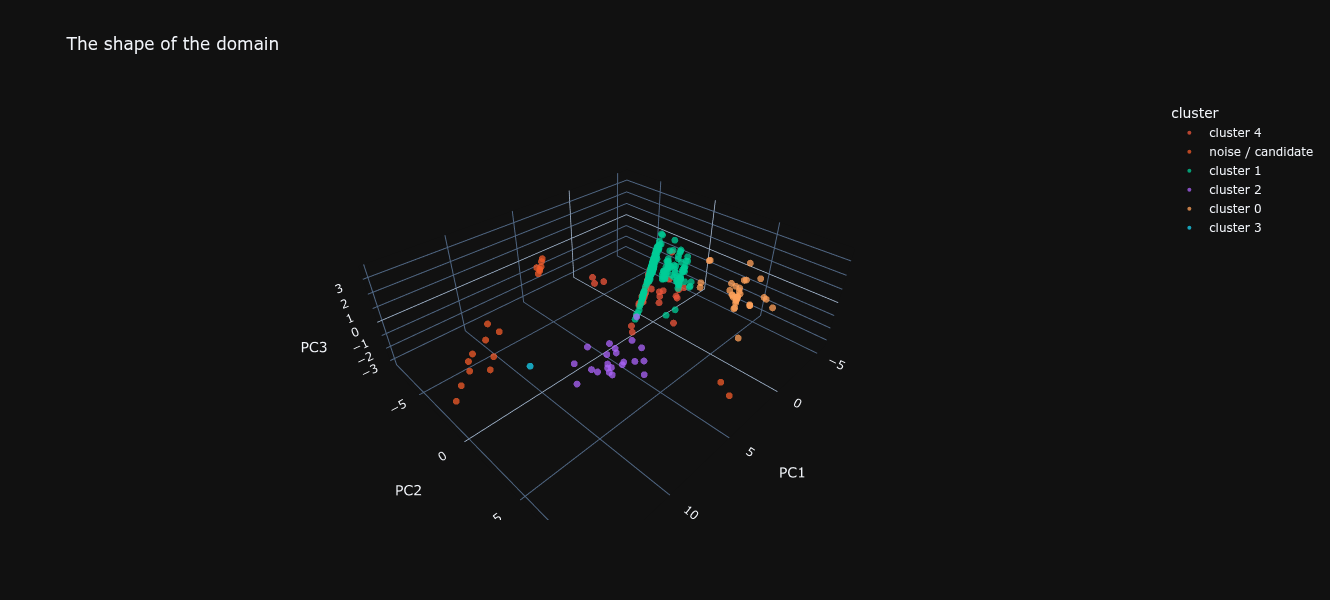

In [7]:
anomaly_map(ml)

## 5 · Steam · Local AI — reading the name

The ML looked at what a group *does*. An analyst also reads what it is *called*. `DOMAIN ADMINS` with these privileges makes sense; `MARKETING-USERS` with the same privileges does not.

### 5.1 · Ask the directory in plain language

No naming convention needed. Describe what you **want** to find — dense embeddings encode topics, not logic, so *"users without admin rights"* returns Domain Admins.

In [9]:
semantic_search(ml, "human resources")

name,similarity,controllables,n_in_path_da,consensus_score
HR-STAFF,0.71,0.000000,0.000000,0.57
HR-DEPARTMENT,0.69,0.000000,0.000000,0.32
HR-USERS,0.66,7.000000,6.000000,0.41
HR-DEPARTMENT-02,0.62,0.000000,0.000000,0.36
HR-ALL,0.62,0.000000,0.000000,0.72
HR-GROUP,0.62,0.000000,0.000000,0.13
HR-MEMBERS,0.62,0.000000,0.000000,0.25
HR-DEPARTMENT-01,0.57,0.000000,0.000000,0.52


### 5.2 · The liars

`incoherence = observed risk (ML) − expected risk (name)`. High and positive: dangerous metrics under a harmless name — review first. Negative: scary name, quiet metrics — forgotten or legacy, don't waste time.

In [10]:
incoherence(ml, n=10)

name,consensus_score,name_privilege_rank,controllables,n_in_path_da
DOMAIN ADMINS,0.99,0.97,3571.000000,717.000000
ENTERPRISE KEY ADMINS,0.98,0.68,2592.000000,1.000000
ENTERPRISE ADMINS,0.96,0.76,3572.000000,1.000000
ENTERPRISE-ADMINS,0.96,0.76,4150.000000,820.000000
SCHEMA-ADMINS,0.95,0.91,3980.000000,780.000000
ADMINISTRATORS,0.95,0.91,3381.000000,101.000000
ADMINISTRATORS-BUILTIN,0.92,0.87,3650.000000,720.000000
KEY-ADMINS,0.90,0.84,2890.000000,450.000000
DOMAIN CONTROLLERS,0.87,1.00,2.000000,0.000000
SCHEMA ADMINS,0.83,0.91,0.000000,0.000000


name,consensus_score,name_privilege_rank,incoherence_score,controllables,controllers,n_in_path_da,members
MARKETING-NEWSLETTER,0.78,0.10,+0.68,58.000000,220.000000,254.000000,33.000000
FINANCE-READONLY,0.96,0.29,+0.67,2450.000000,12.000000,410.000000,1.000000
CAFETERIA-STAFF,0.80,0.20,+0.61,24.000000,142.000000,310.000000,45.000000
VISITOR-WIFI-ACCESS,0.78,0.20,+0.58,38.000000,156.000000,285.000000,62.000000
SUMMER-INTERNS-2019,0.83,0.37,+0.46,67.000000,386.000000,9.000000,19.000000
PRINTER-USERS-FLOOR2,0.77,0.33,+0.44,54.000000,221.000000,12.000000,142.000000
REMOTE MANAGEMENT USERS,0.76,0.34,+0.42,20.000000,217.000000,0.000000,2.000000
REMOTE-WORKERS-VPN,0.76,0.36,+0.40,12.000000,242.000000,18.000000,385.000000
HELPDESK-T1,0.99,0.67,+0.32,2513.000000,379.000000,399.000000,59.000000
REPLICATORS,0.85,0.60,+0.25,0.000000,8.000000,0.000000,2.000000


name,consensus_score,name_privilege_rank,incoherence_score,controllables,n_in_path_da
OPERATIONS-GROUP-03,0.11,0.95,-0.84,0.000000,0.000000
HR-GROUP,0.13,0.95,-0.82,0.000000,0.000000
RESEARCH-DEPARTMENT-01,0.05,0.81,-0.76,0.000000,0.000000
COMPLIANCE-GROUP-01,0.07,0.82,-0.75,0.000000,0.000000
RESEARCH-DEPARTMENT,0.18,0.92,-0.74,0.000000,0.000000
QUALITY-GROUP,0.21,0.95,-0.74,0.000000,0.000000
TRAINING-GROUP-02,0.19,0.92,-0.73,0.000000,0.000000
TRAINING-GROUP,0.25,0.95,-0.70,0.000000,0.000000
COMMUNICATIONS-TEAM,0.09,0.78,-0.69,0.000000,0.000000
OPERATIONS-GROUP,0.28,0.97,-0.68,0.000000,0.000000


### 5.3 · From numbers to a ticket

A small local model (`llama3.2:3b`, CPU is enough) explains each of the top liars: does the privilege level match the name, what is the likely cause, what should the analyst do. It does not diagnose anything the pipeline has not already found — it translates. Prompt, metrics and answer stay together; a human reviews every one before anything changes.

In [11]:
llm_explain(ml, n=3)

llama3.2:3b: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:17<00:00,  5.82s/it]


group,consensus,sounds privileged,incoherence,LLM analysis
MARKETING-NEWSLETTER,0.78,0.10,+0.68,"Here are my answers: 1. The group's privilege level does not match its name, as indicated by the high ML anomaly score (0.78) and low semantic expectation from name (0.10). This is concerning due to the large number of objects controlled (58), members (33), and attack paths to Domain Admin (254). 2. The most likely explanation is a misconfiguration, possibly caused by a recent change in group membership or permissions. 3. I recommend reviewing this group now to determine the cause of the anomaly and ensure its privilege level aligns with its name and actual usage."
FINANCE-READONLY,0.96,0.29,+0.67,"Here are my answers: 1. The group's privilege level does not match its name, as indicated by the ML anomaly score of 0.96, which suggests a high level of deviation from expected behavior. This is further exacerbated by the fact that it appears in 410 attack paths to Domain Admin and has a large number of objects under its control (2450), suggesting excessive privilege. 2. The most likely explanation is a misconfiguration, as the group's name does not reflect its actual privilege level, and there are no indications of a legitimate tier-0 group or legacy configuration that would explain this discrepancy. 3. I recommend reviewing this group immediately to determine if it's a misconfigured group and if any adjustments need to be made to align with expected privilege levels."
CAFETERIA-STAFF,0.80,0.20,+0.61,"Here are my answers: 1. The group's privilege level does not match its name, as a ""cafeteria staff"" sounds like an entry-level or general staff role, but the metrics suggest a high level of access and risk (310 attack paths to Domain Admin, 142 principals that can modify it). 2. The most likely explanation is a misconfiguration, as the group's name does not align with its actual privilege level, suggesting that someone may have accidentally created a highly privileged group without intending to. 3. I recommend reviewing this group immediately to understand its purpose and ensure it is correctly configured, as leaving it unreviewed could lead to security risks due to its high privilege level despite its innocuous-sounding name."


## 6 · Full circle — inspect one group

Type any group name and see what every layer says about it: the deterministic **risk score** (layer 1), the **anomaly consensus** (layer 3), the **incoherence** between what it is called and what it does (layer 4), the reason the ML flagged it — and, if you tick the box, the local LLM's written analysis. One search, the whole boiler.

In [12]:
inspect(ml)

Output()

## Take away the liars…

…and the intruder finds nothing to grab onto. Four layers, one short list, every entry explained — and no data ever left this machine.

*Notebook and module: CC BY 4.0. Questions, fixes or results from your own domain → [grexid.eu](https://grexid.eu)*